# Single-column Python loop

This notebook demonstrates the thin Python layer over `swatsoil.c`.  
Python owns the outer timestep loop; C handles the soil physics per step.

**API used:**
- `_vampscore.soil_init(ini_text, forcing, firststep)` — initialise the solver once  
- `_vampscore.soil_step(i)` — run one external timestep (C canopy + Richards solver)  
- `_vampscore.soil_state_current()` — read all state after the completed step

The result is compared against `Model.run()` to confirm they are identical.

In [1]:
import sys, os, copy
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, '..')
os.environ['VAMPSLIB'] = '../share'

from vampspy import _vampscore
from vampspy.model import Model
from vampspy._io import write_inp_str

## 1. Load the example

`Model.from_file` parses the `.inp` config and loads all forcing time series into numpy arrays.

In [2]:
m = Model.from_file('../examples/fiji/fiji.inp', vampslib='../share')

print(f"steps   : {m.steps}")
print(f"forcing : {list(m.forcing.keys())}")
for k, v in m.forcing.items():
    print(f"  {k:6s}: shape={v.shape}  min={v.min():.3f}  max={v.max():.3f}")

steps   : 61
forcing : ['pre', 'nra', 'ira', 'rlh', 'tem', 'win']
  pre   : shape=(61,)  min=0.000  max=6.532
  nra   : shape=(61,)  min=14.096  max=170.289
  ira   : shape=(61,)  min=27.286  max=246.087
  rlh   : shape=(61,)  min=67.109  max=97.691
  tem   : shape=(61,)  min=18.862  max=24.735
  win   : shape=(61,)  min=0.941  max=3.885


## 2. Prepare the config string

`write_inp_str` serialises the config dict to the INI text the C solver expects.
Forcing arrays are passed separately — no files are written.

In [3]:
cfg = copy.deepcopy(m.config)
cfg.setdefault('time', {})['steps'] = m.steps
# Placeholder names in [ts] — C resolves these against the registered numpy arrays
cfg['ts'] = {name: f'_array_{name}' for name in m.forcing}

ini_text = write_inp_str(cfg, '/dev/null', {}, firststep=1)
print(ini_text[:400], '...')

[vamps]
iniinmem = 1
logging = 0

[determine]
soilmoisture = 1

[soilevaporation]
method = 4

[top]
system = 5

[time]
steps = 61
firststep = 1

[interception]
method = 0
E_avg/R = 0.147
p_f = 0.6
p_tr = 0.017
S = 0.08
St = 0.0062

[canopy]
transpiration = 2
Rnet_absorb = 0.975
method = 2
layers = 1
ra = 7.0
z = 12.7
z_0 = 1.5
d = 7.0
rs = 60

[roots]
swsink = 0
swhypr = 0
swupfu = 0
depth = 120.0 ...


## 3. Run the Python loop

1. `soil_init` registers the forcing arrays and calls `prelim()` inside C — allocates soil layers, reads hydraulic tables, initialises canopy.
2. Each iteration calls `soil_step(i)` which runs the canopy step (`tstep_top`) then the Richards solver (`tstep_soil`) with adaptive internal sub-stepping.
3. `soil_state_current()` returns a dict with scalars and per-layer numpy arrays.

In [4]:
_vampscore.soil_init(ini_text, m.forcing, 1.0)
nlayers = _vampscore.soil_nlayers()
print(f"Solver initialised: {nlayers} soil layers")

# Storage
steps = m.steps
volact = np.zeros(steps)
SMD    = np.zeros(steps)
qbot   = np.zeros(steps)
theta  = np.zeros((steps, nlayers))
h      = np.zeros((steps, nlayers))

for i in range(steps):
    _vampscore.soil_step(i)
    s = _vampscore.soil_state_current()

    volact[i] = s['volact']
    SMD[i]    = s['SMD']
    qbot[i]   = s['qbot']
    theta[i]  = s['theta']
    h[i]      = s['h']

print(f"Done. volact[-1] = {volact[-1]:.4f} cm")

Solver initialised: 77 soil layers
Done. volact[-1] = 79.2449 cm






+-----------------------------------------------------------------------------+
| time              |  running | to_go |   [masbal, it,   err, dt,water_cont] |
+-----------------------------------------------------------------------------+
|        61.000000  |    0 sec.|    0  |   [-0.039,  1,    0,0.000400,79.245] |


## 4. Verify against `Model.run()`

The Python loop must produce bit-identical results to the bulk `run()` call.

In [5]:
ref = m.run()

max_diff_volact = np.max(np.abs(volact - ref['volact']))
max_diff_theta  = np.max(np.abs(theta  - ref['theta']))

print(f"max |volact diff| = {max_diff_volact:.2e}")
print(f"max |theta  diff| = {max_diff_theta:.2e}")
assert max_diff_volact < 1e-10, "volact mismatch!"
assert max_diff_theta  < 1e-10, "theta mismatch!"
print("✓ Python loop matches Model.run() exactly")

max |volact diff| = 0.00e+00
max |theta  diff| = 0.00e+00
✓ Python loop matches Model.run() exactly


|        61.000000  |    0 sec.|    0  |   [-0.039,  1,    0,0.000400,79.245] |


## 5. Inspect what `soil_state_current()` returns

Every key available after each step:

In [6]:
_vampscore.soil_init(ini_text, m.forcing, 1.0)
_vampscore.soil_step(0)
s0 = _vampscore.soil_state_current()

print("Scalars:")
for k, v in sorted(s0.items()):
    if np.ndim(v) == 0:
        print(f"  {k:20s} = {v:.6f}")

print("\nArrays:")
for k, v in sorted(s0.items()):
    if np.ndim(v) > 0:
        print(f"  {k:20s}  shape={np.shape(v)}")

Scalars:
  SMD                  = 11.977107
  _nlayers             = 77.000000
  avgtheta             = 0.449597
  cumeva               = 0.005697
  cumintc              = 0.000000
  cumprec              = 0.000000
  cumtra               = 0.355296
  interception         = 0.000000
  masbal               = -0.000286
  precipitation        = 0.000000
  qbot                 = -0.000129
  qtop                 = 0.005697
  soilevaporation      = 0.005697
  t                    = 1.000000
  transpiration        = 0.355296
  volact               = 69.238008

Arrays:
  gwl                   shape=(2,)
  h                     shape=(77,)
  howsat                shape=(77,)
  inq                   shape=(78,)
  k                     shape=(77,)
  q                     shape=(78,)
  qrot                  shape=(77,)
  theta                 shape=(77,)


## 6. Plot results

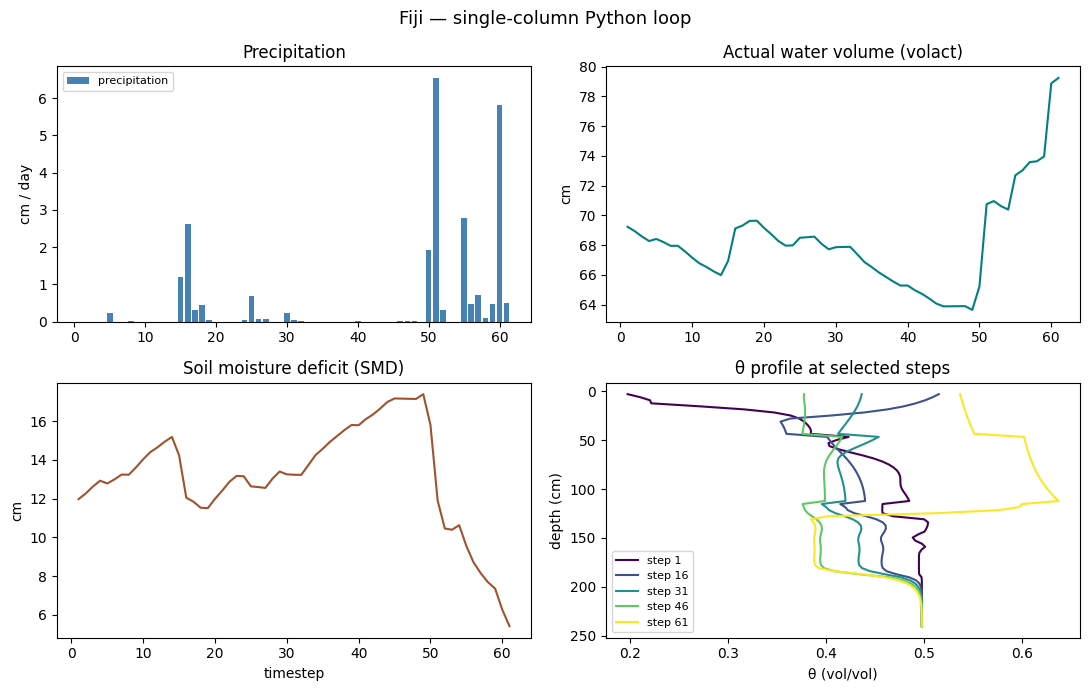

In [7]:
days = np.arange(1, steps + 1)

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
fig.suptitle('Fiji — single-column Python loop', fontsize=13)

ax = axes[0, 0]
ax.bar(days, m.forcing['pre'], color='steelblue', label='precipitation')
ax.set_ylabel('cm / day')
ax.set_title('Precipitation')
ax.legend(fontsize=8)

ax = axes[0, 1]
ax.plot(days, volact, color='teal')
ax.set_ylabel('cm')
ax.set_title('Actual water volume (volact)')

ax = axes[1, 0]
ax.plot(days, SMD, color='sienna')
ax.set_ylabel('cm')
ax.set_title('Soil moisture deficit (SMD)')
ax.set_xlabel('timestep')

ax = axes[1, 1]
depth_cm = np.arange(1, nlayers + 1) * (240.0 / nlayers)
show_steps = [0, 15, 30, 45, 60]
colors = plt.cm.viridis(np.linspace(0, 1, len(show_steps)))
for c, step in zip(colors, show_steps):
    ax.plot(theta[step], depth_cm, color=c, label=f'step {step+1}')
ax.invert_yaxis()
ax.set_xlabel('θ (vol/vol)')
ax.set_ylabel('depth (cm)')
ax.set_title('θ profile at selected steps')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('single_column_loop.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. What happens inside the loop

```
soil_init(ini_text, forcing, firststep)
│
│  C: ts_register_array for each forcing variable
│  C: prelim()  →  reads config from ini_text (in-memory, no file)
│              →  allocates soil layers, hydraulic tables
│              →  init_top()  +  pre_top()  (canopy setup)
│              →  presoil()   (initial θ, h, k profiles)
│
for i in range(steps):
│
│   soil_step(i)
│   │
│   │  C: tstep_top(i, ...)  →  canopy: interception, transpiration, soil-evap
│   │  C: tstep_soil(i, ...)  →  Richards solver with adaptive sub-stepping
│   │                           updates θ, h, k, qrot, howsat, gwl, volact, SMD
│   │
│   soil_state_current()  →  copies C globals into Python dict
│
│   [ Python can inspect or modify state here — future: lateral flow ]
```

The C globals (`theta`, `h`, `k`, etc.) persist between calls within the same `soil_init` session.  
The next `soil_step` picks up exactly where the previous one left off.